In [3]:
from pathlib import Path
import sys

MODULE_DIR = Path("notebooks/26May4-PyramidForcing-multihead")
if not MODULE_DIR.exists():
    MODULE_DIR = Path(".")
module_dir_str = str(MODULE_DIR.resolve())
if module_dir_str not in sys.path:
    sys.path.insert(0, module_dir_str)

from spectral_analysis_utils import run_fft_six_panel


Loaded ../../data/26Mar26-PyramidForcing-frames72/eagle/layer12.pt: layer=12, head=0, frames=72, preprocess=first_difference
Attention diagnostics
  raw: sum=71.9171, min=-2.20508, max=5.49609 at frame 70
  local softmax window: frames 51-71; window sum=1 (normalization is local, not over all 72 frames), min=0.000211499, max=0.46761 at frame 70
  raw frames 60-71:
    [-2.205078 -2.023438 -1.057617 -0.111694  0.445312  0.283203  0.207275
  1.234375  3.0625    4.726562  5.496094  4.625   ]
  local softmax frames 51-71:
    [2.378652e-02 1.791997e-02 7.254479e-03 3.783843e-03 1.952993e-03
 1.954156e-03 2.306532e-03 2.126174e-03 6.419881e-04 2.114985e-04
 2.536255e-04 6.662594e-04 1.715744e-03 2.994728e-03 2.546562e-03
 2.360365e-03 6.592390e-03 4.101923e-02 2.166111e-01 4.676101e-01
 1.956918e-01]
  full softmax plot vector NaN outside frames 51-71; nansum=1
  top raw frames:
    frame 70: 5.49609
    frame 69: 4.72656
    frame 71: 4.625
    frame 26: 3.54688
    frame 68: 3.0625
    fr

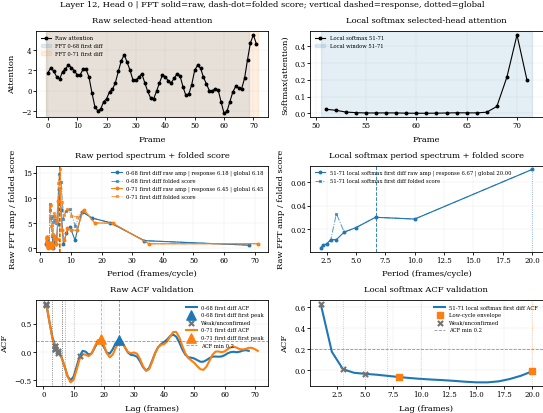

In [2]:
ATTN_DIR = Path("../../data/26Mar26-PyramidForcing-frames72/eagle")
LAYER = 12
HEAD = 0

FFT_RANGES = [
    {"label": "0-68 first diff", "start": 0, "end": 69},
    {"label": "0-71 first diff", "start": 0, "end": None},
]

SOFTMAX_WINDOW_START = 51
SOFTMAX_WINDOW_END = 72
SOFTMAX_WINDOW_LABEL = "51-71"
SOFTMAX_FFT_RANGES = [
    {"label": f"{SOFTMAX_WINDOW_LABEL} local softmax first diff", "start": 0, "end": None},
]

PERIOD_MIN = 2.0
PERIOD_MAX = None
RESPONSE_PERIOD_MIN = 4.0
RESPONSE_PERIOD_MAX = 18.0
MIN_RESPONSE_CYCLES = 3.0

FFT_TOP_K = 5
ACF_TOL = 2
ACF_MIN = 0.2
NEAR_TIE_RATIO = 1.05
LOW_CYCLE_THRESHOLD = 3.0

HARMONIC_FOLDING_ENABLED = True
HARMONIC_FOLD_MIN_PERIOD = 3.0
HARMONIC_FOLD_MAX_PERIOD_DIVISOR = 6.0
HARMONIC_FOLD_MAX_MULTIPLE = 4
HARMONIC_FOLD_TOL = 0.2
HARMONIC_FOLD_DECAY = 0.5
FFT_DEBUG_TOP_K = 3

REMOVE_DC = True
APPLY_WINDOW = True
SOFTMAX_TEMPERATURE = 1.0

SAVE_MAIN_FIGURE = True
MAIN_FIGURE_DPI = 300
MAIN_FIGURE_SIZE = (5.50, 4.20)
OUTPUT_DIR = Path("../../figures/26May4-PyramidForcing-multihead")
MAIN_FIGURE_PATH = OUTPUT_DIR / f"spectral_analysis_L{LAYER}H{HEAD}_firstdiff_main.png"

fft_result = run_fft_six_panel(
    attn_dir=ATTN_DIR,
    layer=LAYER,
    head=HEAD,
    fft_ranges=FFT_RANGES,
    softmax_window_start=SOFTMAX_WINDOW_START,
    softmax_window_end=SOFTMAX_WINDOW_END,
    softmax_window_label=SOFTMAX_WINDOW_LABEL,
    softmax_fft_ranges=SOFTMAX_FFT_RANGES,
    period_min=PERIOD_MIN,
    period_max=PERIOD_MAX,
    response_period_min=RESPONSE_PERIOD_MIN,
    response_period_max=RESPONSE_PERIOD_MAX,
    min_response_cycles=MIN_RESPONSE_CYCLES,
    fft_top_k=FFT_TOP_K,
    acf_tol=ACF_TOL,
    acf_min=ACF_MIN,
    near_tie_ratio=NEAR_TIE_RATIO,
    low_cycle_threshold=LOW_CYCLE_THRESHOLD,
    harmonic_folding_enabled=HARMONIC_FOLDING_ENABLED,
    harmonic_fold_min_period=HARMONIC_FOLD_MIN_PERIOD,
    harmonic_fold_max_period_divisor=HARMONIC_FOLD_MAX_PERIOD_DIVISOR,
    harmonic_fold_max_multiple=HARMONIC_FOLD_MAX_MULTIPLE,
    harmonic_fold_tol=HARMONIC_FOLD_TOL,
    harmonic_fold_decay=HARMONIC_FOLD_DECAY,
    fft_debug_top_k=FFT_DEBUG_TOP_K,
    remove_dc=REMOVE_DC,
    apply_window=APPLY_WINDOW,
    softmax_temperature=SOFTMAX_TEMPERATURE,
    save_main_figure=SAVE_MAIN_FIGURE,
    main_figure_dpi=MAIN_FIGURE_DPI,
    main_figure_size=MAIN_FIGURE_SIZE,
    output_dir=OUTPUT_DIR,
    main_figure_path=MAIN_FIGURE_PATH,
)
